# 🔍 Notebook 04: Product Recommendation – KNN

**Đồ án:** Xây dựng hệ thống E-commerce tích hợp Machine Learning

**Mục tiêu:** Gợi ý 5-10 sản phẩm tương tự khi user xem 1 sản phẩm (Content-based Filtering).

**Thuật toán:** K-Nearest Neighbors (KNN) với Cosine Similarity

**Notebook này thực hiện:**
1. Load dữ liệu giao dịch đã clean từ Notebook 01
2. Feature Engineering: TF-IDF (mô tả) + numeric features (giá, tần suất)
3. Build KNN model với cosine distance
4. Test recommendations cho các sản phẩm mẫu
5. Evaluation: Hit Rate
6. Export model + artifacts

---

> ⚠️ **Yêu cầu:** Chạy Notebook 01 trước để tạo `transactions_clean.csv`.

## 0. Setup & Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import warnings

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import hstack, csr_matrix

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('✅ Import thành công!')

✅ Import thành công!


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/ecommerce-ml'
DATA_DIR = f'{PROJECT_DIR}/data'
MODEL_DIR = f'{PROJECT_DIR}/models'

Mounted at /content/drive


## 1. Load & Chuẩn bị dữ liệu sản phẩm

In [3]:
# Load transactions đã clean
df = pd.read_csv(f'{DATA_DIR}/transactions_clean.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f'✅ Loaded transactions: {df.shape}')
df.head()

✅ Loaded transactions: (802679, 13)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancelled,TotalPrice,Hour,DayOfWeek,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,0,83.4,7,1,12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,0,81.0,7,1,12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,0,81.0,7,1,12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,0,100.8,7,1,12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,0,30.0,7,1,12


In [4]:
# ═══════════════════════════════════════════════════
# TẠO PRODUCT FEATURES TABLE
# ═══════════════════════════════════════════════════
# Mỗi sản phẩm (StockCode) tạo 1 feature vector

product_features = df.groupby('StockCode').agg(
    description=('Description', lambda x: x.mode().iloc[0] if not x.mode().empty else ''),
    avg_price=('Price', 'mean'),
    purchase_count=('Invoice', 'nunique'),        # Số đơn chứa SP này
    total_qty_sold=('Quantity', 'sum'),            # Tổng SL bán
    avg_qty_per_order=('Quantity', 'mean'),         # SL trung bình mỗi đơn
    num_customers=('Customer ID', 'nunique'),      # Số KH mua SP này
).reset_index()

# Loại bỏ sản phẩm không có mô tả
product_features = product_features[
    product_features['description'].notna() &
    (product_features['description'].str.strip() != '')
].reset_index(drop=True)

# Loại bỏ sản phẩm chỉ xuất hiện 1 lần (noise)
product_features = product_features[
    product_features['purchase_count'] >= 2
].reset_index(drop=True)

print(f'📊 Product Features Table: {product_features.shape}')
print(f'   Số sản phẩm: {len(product_features):,}')
product_features.head(10)

📊 Product Features Table: (4499, 7)
   Số sản phẩm: 4,499


,StockCode,description,avg_price,purchase_count,total_qty_sold,avg_qty_per_order,num_customers
0,10002,INFLATABLE POLITICAL GLOBE,0.841388,297,8624,27.205047,164
1,10080,GROOVY CACTUS INFLATABLE,0.509259,26,303,11.222222,23
2,10120,DOGGY RUBBER,0.210000,62,664,10.060606,52
3,10123C,HEARTS WRAPPING TAPE,0.624000,46,632,12.640000,39
4,10123G,ARMY CAMO WRAPPING TAPE,0.559231,12,2246,172.769231,12
5,10124A,SPOTS ON RED BOOKCOVER TAPE,0.420000,18,62,3.263158,18
6,10124G,ARMY CAMO BOOKCOVER TAPE,0.420000,9,37,3.700000,9
7,10125,MINI FUNKY DESIGN TAPES,0.817669,120,2016,15.157895,87
8,10133,COLOURING PENCILS BROWN TUBE,0.659528,203,3351,15.806604,153
9,10134,COLOURING PENCILS BROWN TUBE,1.242692,48,614,11.807692,44


In [5]:
# Thống kê sản phẩm
print('📊 Product Statistics:')
print(product_features[['avg_price', 'purchase_count', 'total_qty_sold',
                          'num_customers']].describe().round(2))

📊 Product Statistics:
       avg_price  purchase_count  total_qty_sold  num_customers
count    4499.00         4499.00         4499.00        4499.00
mean        3.76          170.26         2357.33         106.89
std         8.83          281.18         5736.37         135.93
min         0.05            2.00            2.00           1.00
25%         1.19           20.00          139.00          18.00
50%         2.06           69.00          679.00          56.00
75%         3.92          194.00         2154.00         141.00
max       243.68         4895.00       109169.00        1490.00


## 2. Feature Engineering

### 2.1. TF-IDF trên mô tả sản phẩm

Chuyển text description thành vector số bằng TF-IDF. Đây là thành phần chính của Content-based Filtering.

In [6]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=500,      # Giới hạn 500 từ quan trọng nhất
    stop_words='english',  # Loại bỏ stop words
    ngram_range=(1, 2),    # Unigrams + Bigrams
    min_df=2,              # Từ phải xuất hiện ít nhất 2 lần
    max_df=0.95,           # Loại bỏ từ xuất hiện > 95% documents
)

tfidf_matrix = tfidf.fit_transform(product_features['description'].fillna(''))

print(f'✅ TF-IDF Shape: {tfidf_matrix.shape}')
print(f'   Vocabulary size: {len(tfidf.vocabulary_):,} terms')

# Top 20 terms
feature_names = tfidf.get_feature_names_out()
tfidf_sums = tfidf_matrix.sum(axis=0).A1
top_terms = sorted(zip(feature_names, tfidf_sums), key=lambda x: x[1], reverse=True)[:20]

print('\n📝 Top 20 TF-IDF Terms:')
for term, score in top_terms:
    bar = '█' * int(score / max(tfidf_sums) * 30)
    print(f'  {term:25s} {score:.2f} {bar}')

✅ TF-IDF Shape: (4499, 500)
   Vocabulary size: 500 terms

📝 Top 20 TF-IDF Terms:
  set                       155.83 ██████████████████████████████
  pink                      139.10 ██████████████████████████
  blue                      118.25 ██████████████████████
  heart                     95.71 ██████████████████
  glass                     90.62 █████████████████
  red                       87.93 ████████████████
  vintage                   86.18 ████████████████
  white                     83.78 ████████████████
  candle                    79.78 ███████████████
  flower                    71.99 █████████████
  christmas                 70.84 █████████████
  bag                       70.55 █████████████
  box                       69.65 █████████████
  rose                      64.99 ████████████
  design                    63.46 ████████████
  black                     63.11 ████████████
  silver                    62.46 ████████████
  small                     61.21 ██████████

### 2.2. Combine TF-IDF với Numeric Features

Kết hợp text features (TF-IDF) với numeric features (giá, tần suất) để KNN xét cả nội dung lẫn đặc tính sản phẩm.

In [7]:
# Scale numeric features về 0-1 (cùng range với TF-IDF)
numeric_features = ['avg_price', 'purchase_count', 'total_qty_sold',
                     'avg_qty_per_order', 'num_customers']

scaler_product = MinMaxScaler()  # 0-1 range, phù hợp với TF-IDF
numeric_scaled = scaler_product.fit_transform(
    product_features[numeric_features].fillna(0)
)

# Kết hợp: TF-IDF (sparse) + Numeric (dense → sparse)
# Cho numeric features trọng số thấp hơn vì TF-IDF đã mang nhiều thông tin
NUMERIC_WEIGHT = 0.3  # Trọng số cho numeric (TF-IDF = 1.0)

numeric_sparse = csr_matrix(numeric_scaled * NUMERIC_WEIGHT)
combined_features = hstack([tfidf_matrix, numeric_sparse])

print(f'✅ Combined Features Matrix: {combined_features.shape}')
print(f'   TF-IDF features: {tfidf_matrix.shape[1]}')
print(f'   Numeric features: {len(numeric_features)} (×{NUMERIC_WEIGHT} weight)')
print(f'   Total features: {combined_features.shape[1]}')

✅ Combined Features Matrix: (4499, 505)
   TF-IDF features: 500
   Numeric features: 5 (×0.3 weight)
   Total features: 505


## 3. Build KNN Model

In [8]:
# KNN với Cosine Similarity
N_NEIGHBORS = 11  # 10 neighbors + 1 (chính nó)

knn = NearestNeighbors(
    n_neighbors=N_NEIGHBORS,
    metric='cosine',       # Cosine distance (1 - cosine_similarity)
    algorithm='brute',     # Brute force cho sparse matrix
    n_jobs=-1
)

print('🔧 Fitting KNN model...')
knn.fit(combined_features)

print(f'✅ KNN model fitted!')
print(f'   N neighbors: {N_NEIGHBORS - 1} (excluding self)')
print(f'   Metric: cosine similarity')
print(f'   Products in index: {combined_features.shape[0]:,}')

🔧 Fitting KNN model...
✅ KNN model fitted!
   N neighbors: 10 (excluding self)
   Metric: cosine similarity
   Products in index: 4,499


In [9]:
# Tạo mapping StockCode → Index và ngược lại
stock_to_idx = dict(zip(product_features['StockCode'], range(len(product_features))))
idx_to_stock = dict(zip(range(len(product_features)), product_features['StockCode']))

def get_recommendations(stock_code, top_k=10):
    """Lấy top_k sản phẩm tương tự cho 1 sản phẩm."""
    if stock_code not in stock_to_idx:
        return None

    idx = stock_to_idx[stock_code]
    distances, indices = knn.kneighbors(
        combined_features[idx].reshape(1, -1),
        n_neighbors=top_k + 1  # +1 vì kết quả đầu tiên là chính nó
    )

    results = []
    for i, (dist, neighbor_idx) in enumerate(zip(distances[0], indices[0])):
        if i == 0:  # Bỏ chính nó
            continue
        neighbor_stock = idx_to_stock[neighbor_idx]
        neighbor_info = product_features[product_features['StockCode'] == neighbor_stock].iloc[0]
        results.append({
            'rank': i,
            'stock_code': neighbor_stock,
            'description': neighbor_info['description'],
            'price': neighbor_info['avg_price'],
            'similarity': 1 - dist,  # Cosine similarity = 1 - cosine distance
        })

    return pd.DataFrame(results)

print('✅ Recommendation function đã sẵn sàng!')

✅ Recommendation function đã sẵn sàng!


## 4. Test Recommendations

In [10]:
# Chọn 5 sản phẩm bán chạy nhất để test
top_products = product_features.nlargest(5, 'purchase_count')

for _, product in top_products.iterrows():
    stock_code = product['StockCode']
    desc = product['description']
    price = product['avg_price']

    print('=' * 80)
    print(f'🛍️ SẢN PHẨM: {desc}')
    print(f'   StockCode: {stock_code} | Giá: £{price:.2f} | Lượt mua: {product["purchase_count"]:,}')
    print('-' * 80)

    recs = get_recommendations(stock_code, top_k=5)
    if recs is not None:
        for _, rec in recs.iterrows():
            sim_bar = '█' * int(rec['similarity'] * 20)
            print(f'  {rec["rank"]}. [{rec["stock_code"]}] {rec["description"][:50]:50s} '
                  f'£{rec["price"]:6.2f} | Sim: {rec["similarity"]:.3f} {sim_bar}')
    print()

🛍️ SẢN PHẨM: WHITE HANGING HEART T-LIGHT HOLDER
   StockCode: 85123A | Giá: £2.87 | Lượt mua: 4,895
--------------------------------------------------------------------------------
  1. [21733] RED HANGING HEART T-LIGHT HOLDER                   £  2.92 | Sim: 0.869 █████████████████
  2. [84970S] HANGING HEART ZINC T-LIGHT HOLDER                  £  0.85 | Sim: 0.833 ████████████████
  3. [84978] HANGING HEART JAR T-LIGHT HOLDER                   £  1.23 | Sim: 0.818 ████████████████
  4. [23273] HEART T-LIGHT HOLDER WILLIE WINKIE                 £  1.68 | Sim: 0.641 ████████████
  5. [85118] HEART T-LIGHT HOLDER                               £  0.91 | Sim: 0.639 ████████████

🛍️ SẢN PHẨM: REGENCY CAKESTAND 3 TIER
   StockCode: 22423 | Giá: £12.46 | Lượt mua: 3,317
--------------------------------------------------------------------------------
  1. [22776] SWEETHEART CAKESTAND 3 TIER                        £  9.84 | Sim: 0.543 ██████████
  2. [23164] REGENCY CAKE SLICE                

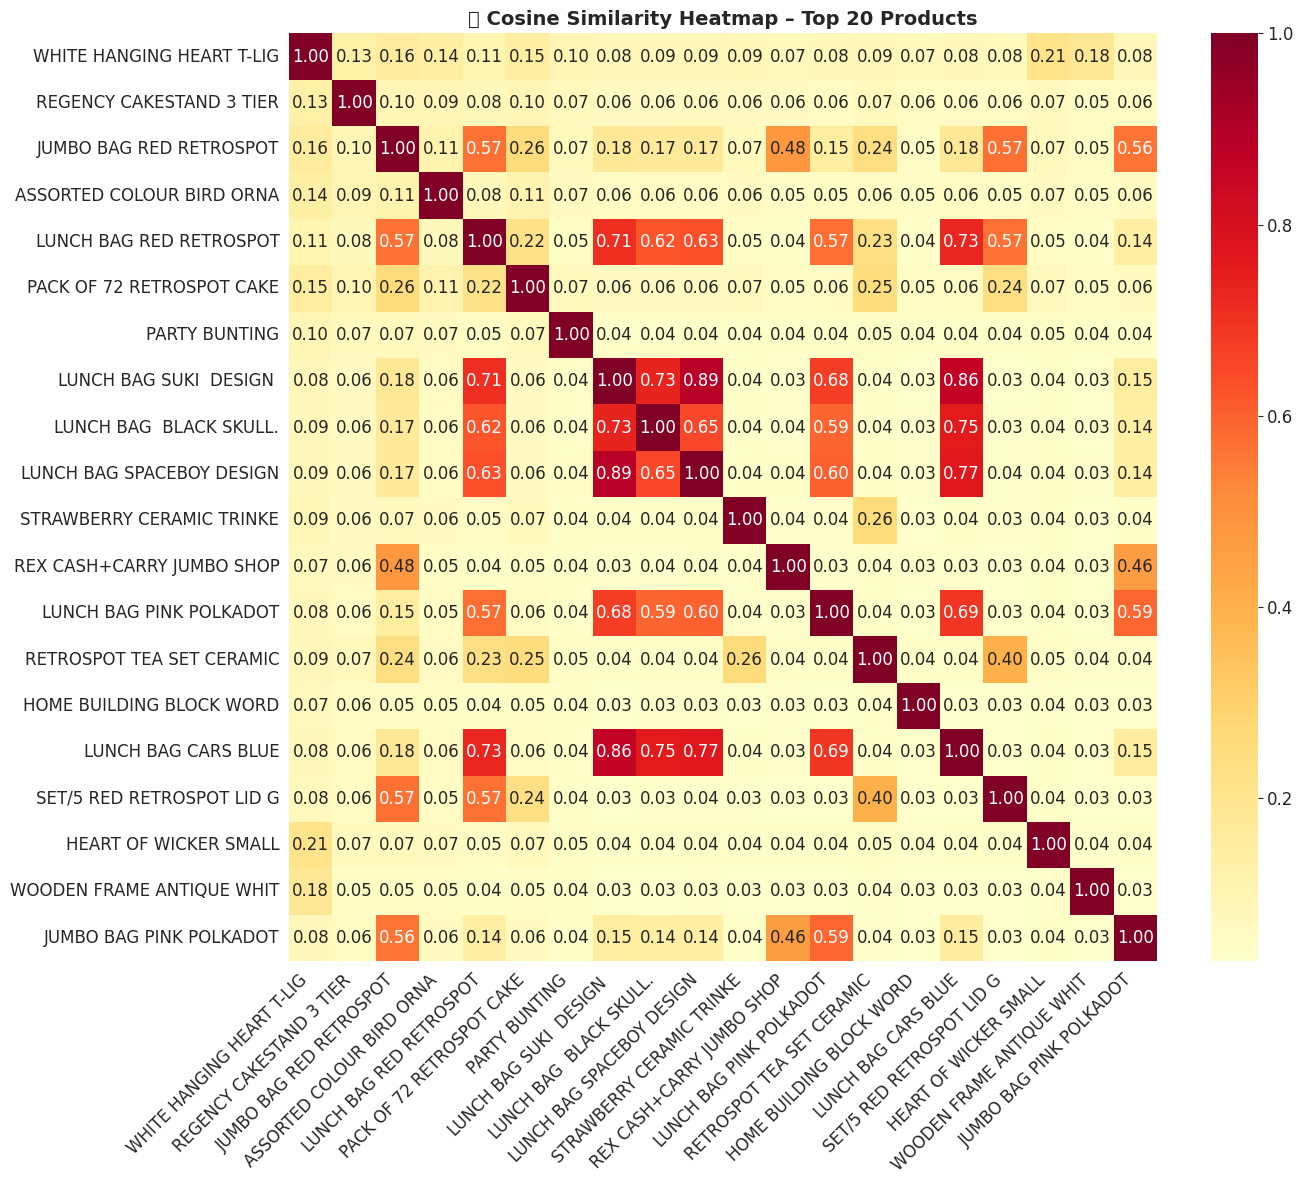

In [11]:
# Visualization: Similarity heatmap cho top 20 sản phẩm
top20_stocks = product_features.nlargest(20, 'purchase_count')['StockCode'].values
top20_indices = [stock_to_idx[s] for s in top20_stocks if s in stock_to_idx]
top20_names = [product_features[product_features['StockCode'] == idx_to_stock[i]]['description'].values[0][:25]
                for i in top20_indices]

# Tính similarity matrix
from sklearn.metrics.pairwise import cosine_similarity
sim_matrix = cosine_similarity(combined_features[top20_indices])

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(sim_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=top20_names, yticklabels=top20_names, ax=ax)
ax.set_title('🔥 Cosine Similarity Heatmap – Top 20 Products', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Evaluation: Hit Rate

**Hit Rate** = Trong lịch sử giao dịch, khi khách mua sản phẩm A, bao nhiêu % sản phẩm được gợi ý (top-10 similar) cũng được khách đó mua?

Đây là proxy metric cho chất lượng recommendation khi chưa có A/B test.

📊 Khách hàng active (≥ 5 SP): 5,538
🔍 Evaluating Hit Rate on 500 customers...

📊 HIT RATE EVALUATION (Top-10 Recommendations)
  Overall Hit Rate: 0.7215 (72.2%)
  Avg Customer Hit Rate: 0.6117 (61.2%)
  Total queries: 42,211
  Total hits: 30,457


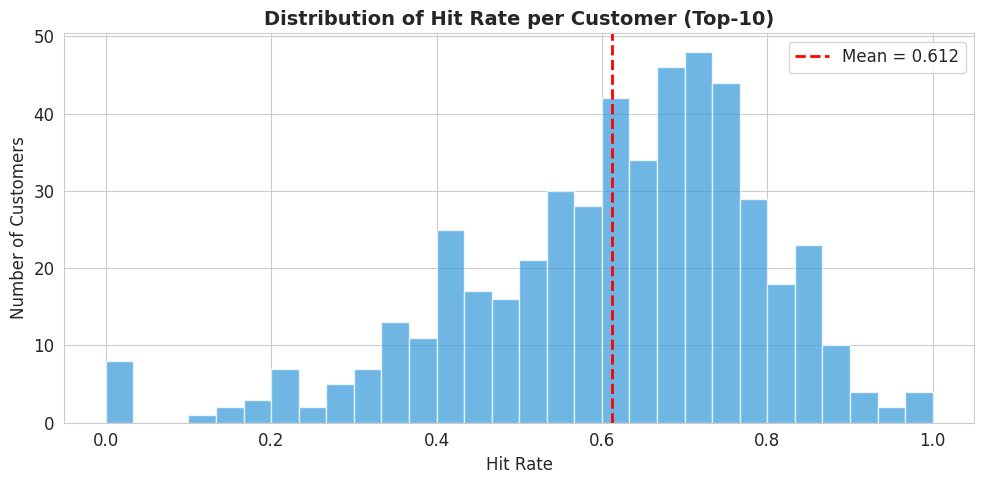

In [ ]:
# Tạo customer-product co-purchase matrix
# Với mỗi khách hàng, lấy danh sách sản phẩm đã mua
customer_products = df.groupby('Customer ID')['StockCode'].apply(set).to_dict()

# Lấy khách hàng đã mua >= 5 sản phẩm khác nhau
active_customers = {cid: prods for cid, prods in customer_products.items()
                     if len(prods) >= 5}

print(f'📊 Khách hàng active (≥ 5 SP): {len(active_customers):,}')

# Tính Hit Rate
TOP_K = 10
hits = 0
total = 0
per_customer_hits = []

# Sample 500 khách để tính nhanh
sample_customers = list(active_customers.items())[:500]

print(f'🔍 Evaluating Hit Rate on {len(sample_customers)} customers...')

for cid, purchased_products in sample_customers:
    customer_hits = 0
    customer_total = 0

    for product in purchased_products:
        if product not in stock_to_idx:
            continue

        recs = get_recommendations(product, top_k=TOP_K)
        if recs is None:
            continue

        recommended_stocks = set(recs['stock_code'].values)
        overlap = recommended_stocks & purchased_products

        if len(overlap) > 0:
            customer_hits += 1
        customer_total += 1

    if customer_total > 0:
        per_customer_hits.append(customer_hits / customer_total)
        hits += customer_hits
        total += customer_total

overall_hit_rate = hits / max(total, 1)
avg_customer_hit_rate = np.mean(per_customer_hits) if per_customer_hits else 0

print(f'\n' + '=' * 60)
print(f'📊 HIT RATE EVALUATION (Top-{TOP_K} Recommendations)')
print(f'=' * 60)
print(f'  Overall Hit Rate: {overall_hit_rate:.4f} ({overall_hit_rate*100:.1f}%)')
print(f'  Avg Customer Hit Rate: {avg_customer_hit_rate:.4f} ({avg_customer_hit_rate*100:.1f}%)')
print(f'  Total queries: {total:,}')
print(f'  Total hits: {hits:,}')

# Distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(per_customer_hits, bins=30, color='#3498db', alpha=0.7, edgecolor='white')
ax.axvline(x=avg_customer_hit_rate, color='red', linestyle='--', linewidth=2,
            label=f'Mean = {avg_customer_hit_rate:.3f}')
ax.set_title(f'Distribution of Hit Rate per Customer (Top-{TOP_K})',
              fontsize=14, fontweight='bold')
ax.set_xlabel('Hit Rate')
ax.set_ylabel('Number of Customers')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 6. Export Model & Artifacts

In [ ]:
import os
os.makedirs(MODEL_DIR, exist_ok=True)

# 1. Save KNN model
knn_path = f'{MODEL_DIR}/knn_model.joblib'
joblib.dump(knn, knn_path)
print(f'✅ KNN model → {knn_path}')

# 2. Save TF-IDF vectorizer
tfidf_path = f'{MODEL_DIR}/tfidf_vectorizer.joblib'
joblib.dump(tfidf, tfidf_path)
print(f'✅ TF-IDF vectorizer → {tfidf_path}')

# 3. Save product scaler
scaler_prod_path = f'{MODEL_DIR}/scaler_product.joblib'
joblib.dump(scaler_product, scaler_prod_path)
print(f'✅ Product scaler → {scaler_prod_path}')

# 4. Save combined features matrix (pre-computed)
features_path = f'{MODEL_DIR}/product_features_matrix.joblib'
joblib.dump(combined_features, features_path)
print(f'✅ Features matrix → {features_path}')

# 5. Save product lookup table
product_lookup = product_features[['StockCode', 'description', 'avg_price',
                                     'purchase_count', 'num_customers']].copy()
product_lookup_path = f'{DATA_DIR}/product_lookup.csv'
product_lookup.to_csv(product_lookup_path, index=False)
print(f'✅ Product lookup → {product_lookup_path}')

# 6. Save mappings
mappings = {
    'stock_to_idx': {str(k): int(v) for k, v in stock_to_idx.items()},
    'idx_to_stock': {str(k): str(v) for k, v in idx_to_stock.items()},
}
mappings_path = f'{MODEL_DIR}/product_mappings.json'
with open(mappings_path, 'w') as f:
    json.dump(mappings, f)
print(f'✅ Product mappings → {mappings_path}')

# 7. Save KNN config
knn_config = {
    'n_neighbors': N_NEIGHBORS - 1,
    'metric': 'cosine',
    'tfidf_max_features': 500,
    'numeric_features': numeric_features,
    'numeric_weight': NUMERIC_WEIGHT,
    'total_products': len(product_features),
    'hit_rate': overall_hit_rate,
    'avg_customer_hit_rate': avg_customer_hit_rate,
}
knn_config_path = f'{MODEL_DIR}/knn_config.json'
with open(knn_config_path, 'w') as f:
    json.dump(knn_config, f, indent=2, default=str)
print(f'✅ KNN config → {knn_config_path}')

print('\n' + '=' * 60)
print('🎉 HOÀN TẤT NOTEBOOK 04!')
print('Tiếp tục với Notebook 05: Retrain RF + Final Evaluation')
print('=' * 60)

✅ KNN model → /content/drive/MyDrive/ecommerce-ml/models/knn_model.joblib
✅ TF-IDF vectorizer → /content/drive/MyDrive/ecommerce-ml/models/tfidf_vectorizer.joblib
✅ Product scaler → /content/drive/MyDrive/ecommerce-ml/models/scaler_product.joblib
✅ Features matrix → /content/drive/MyDrive/ecommerce-ml/models/product_features_matrix.joblib
✅ Product lookup → /content/drive/MyDrive/ecommerce-ml/data/product_lookup.csv
✅ Product mappings → /content/drive/MyDrive/ecommerce-ml/models/product_mappings.json
✅ KNN config → /content/drive/MyDrive/ecommerce-ml/models/knn_config.json

🎉 HOÀN TẤT NOTEBOOK 04!
Tiếp tục với Notebook 05: Retrain RF + Final Evaluation
